<a href="https://colab.research.google.com/github/sarahibadi/Adult_Census-/blob/main/Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1/8: Loading dataset from OpenML...
  Shapes: (39073, 14) (9769, 14) | positive rate test: 0.239
Step 2/8: Building preprocessors...
Step 3/8: Defining helpers...
Step 4/8: Training Decision Tree (GridSearchCV)...

=== Decision Tree ===
Best params: {'model__criterion': 'gini', 'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__min_samples_split': 20}
CV best ROC AUC: 0.9

Test metrics:
               precision    recall  f1-score   support

           0     0.8822    0.9417    0.9110      7431
           1     0.7643    0.6005    0.6726      2338

    accuracy                         0.8601      9769
   macro avg     0.8233    0.7711    0.7918      9769
weighted avg     0.8540    0.8601    0.8540      9769

Test ROC AUC: 0.9065


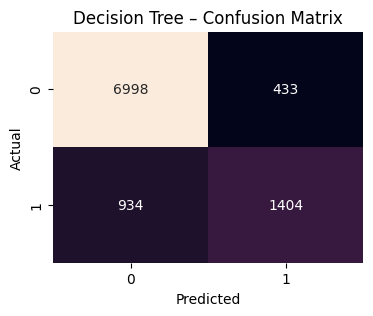

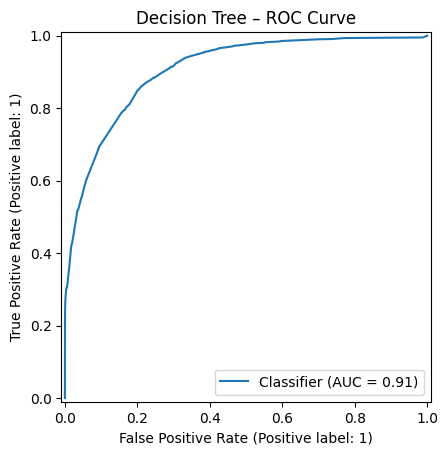

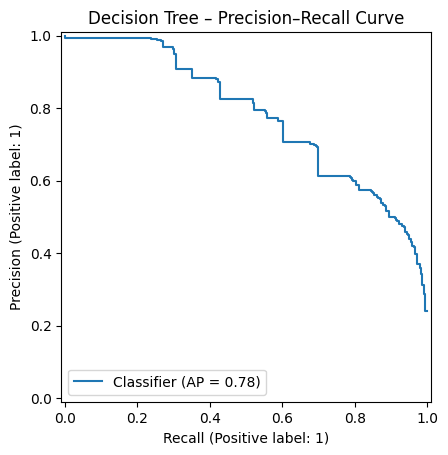

Step 5/8: Training Random Forest (GridSearchCV)...

=== Random Forest ===
Best params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 3, 'model__n_estimators': 300}
CV best ROC AUC: 0.9163

Test metrics:
               precision    recall  f1-score   support

           0     0.8855    0.9479    0.9156      7431
           1     0.7867    0.6104    0.6874      2338

    accuracy                         0.8671      9769
   macro avg     0.8361    0.7791    0.8015      9769
weighted avg     0.8618    0.8671    0.8610      9769

Test ROC AUC: 0.9181


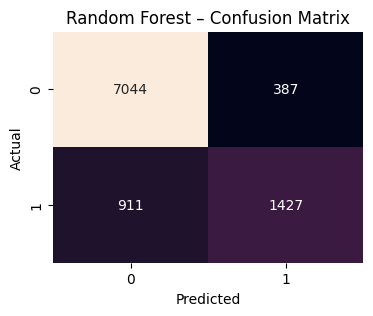

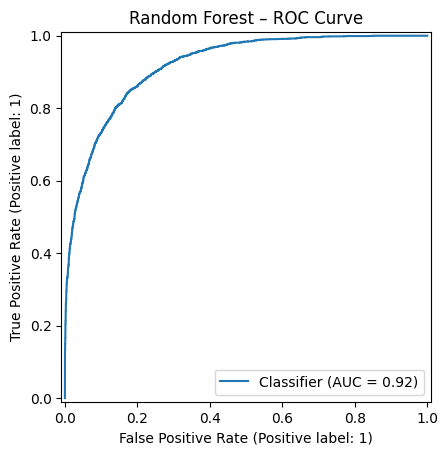

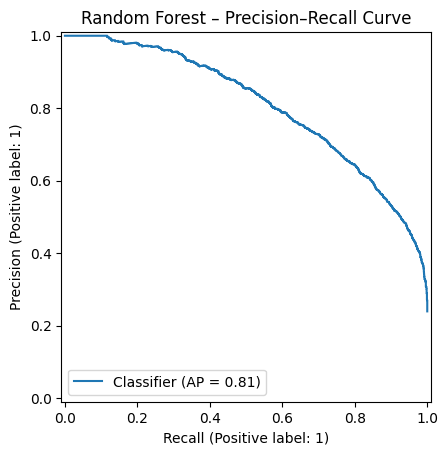

Step 6/8: Training AdaBoost (GridSearchCV)...

=== AdaBoost ===
Best params: {'model__learning_rate': 0.5, 'model__n_estimators': 300}
CV best ROC AUC: 0.9106

Test metrics:
               precision    recall  f1-score   support

           0     0.8727    0.9498    0.9096      7431
           1     0.7781    0.5595    0.6509      2338

    accuracy                         0.8564      9769
   macro avg     0.8254    0.7546    0.7803      9769
weighted avg     0.8500    0.8564    0.8477      9769

Test ROC AUC: 0.911


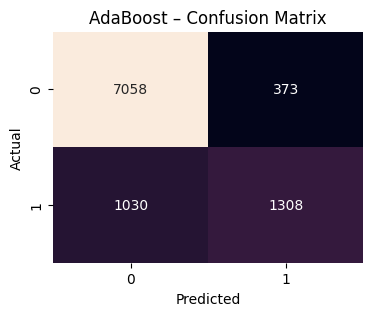

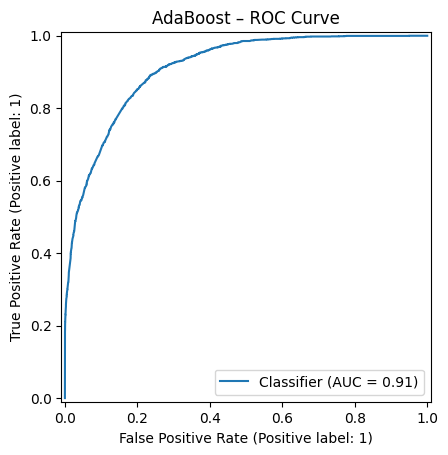

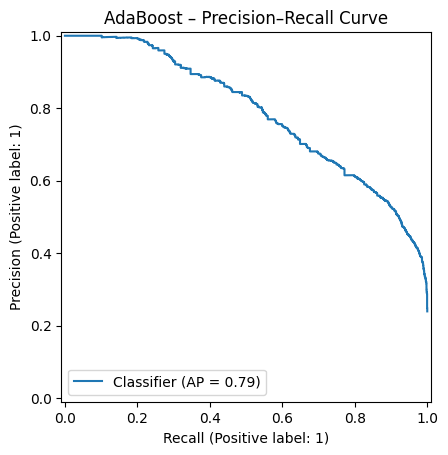

Step 7/8: Training XGBoost (GridSearchCV)...

=== XGBoost ===
Best params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 400, 'model__subsample': 0.8}
CV best ROC AUC: 0.9269

Test metrics:
               precision    recall  f1-score   support

           0     0.8954    0.9468    0.9204      7431
           1     0.7933    0.6484    0.7136      2338

    accuracy                         0.8754      9769
   macro avg     0.8443    0.7976    0.8170      9769
weighted avg     0.8710    0.8754    0.8709      9769

Test ROC AUC: 0.9297


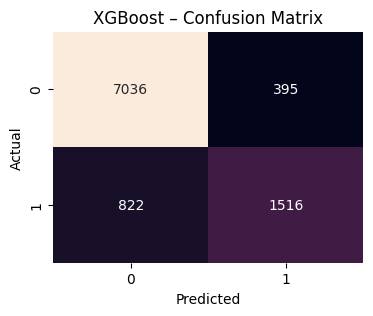

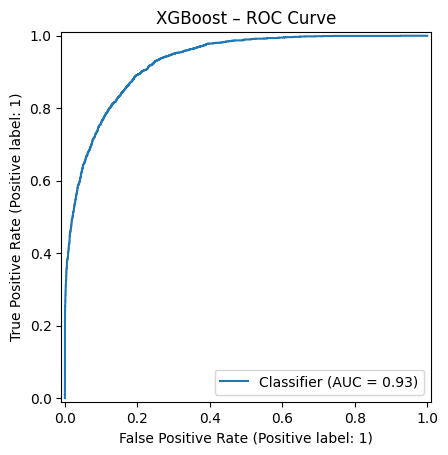

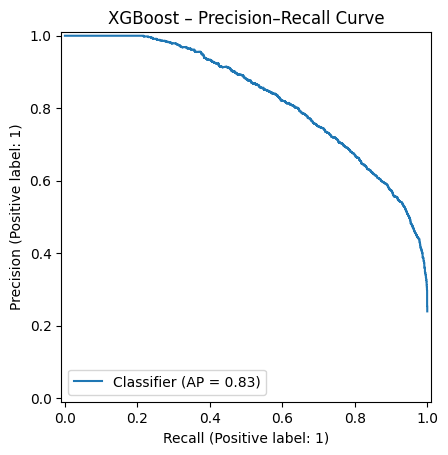

Step 8/8: Model comparison plots...


<Figure size 600x500 with 0 Axes>

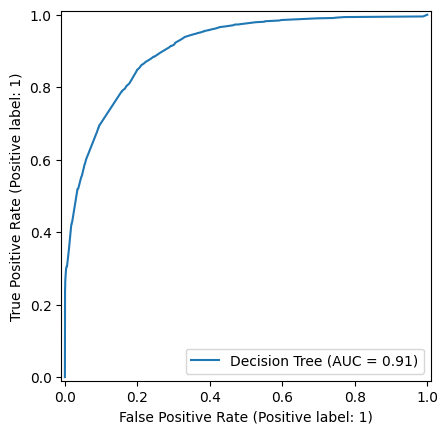

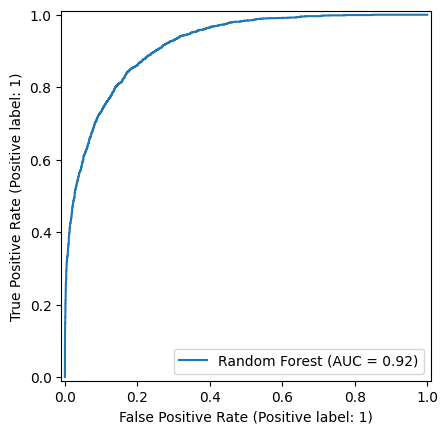

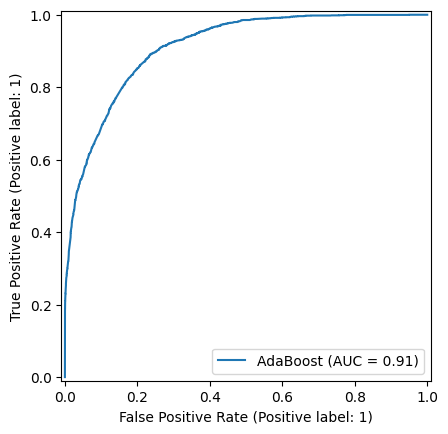

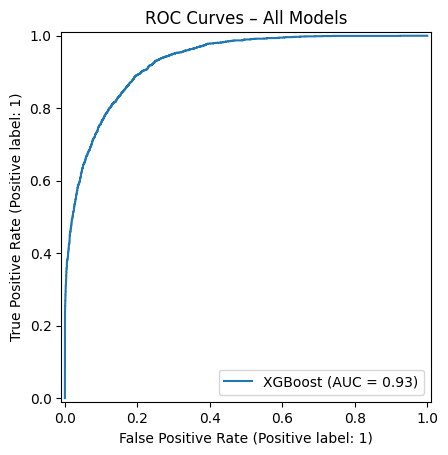

<Figure size 600x500 with 0 Axes>

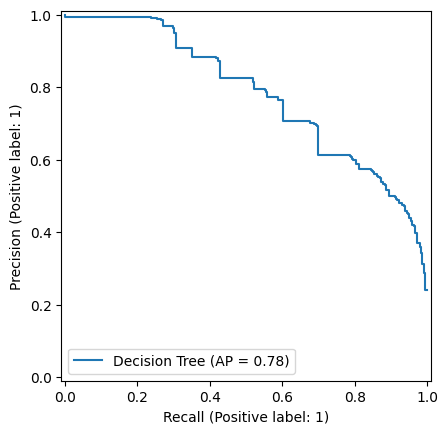

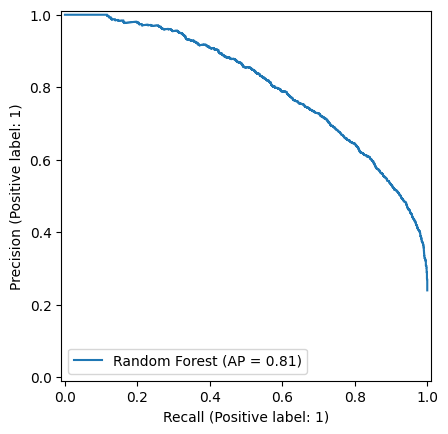

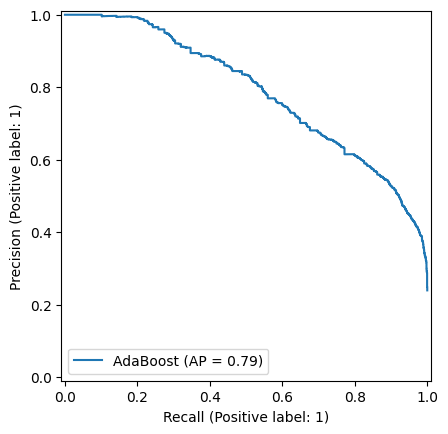

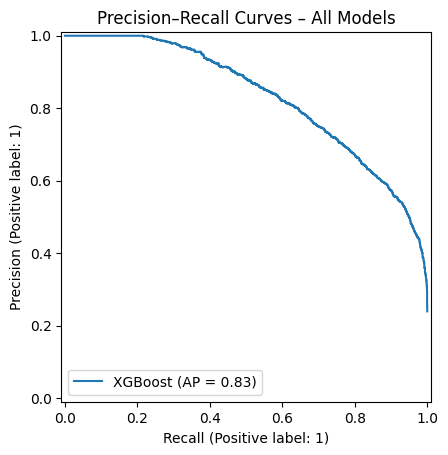

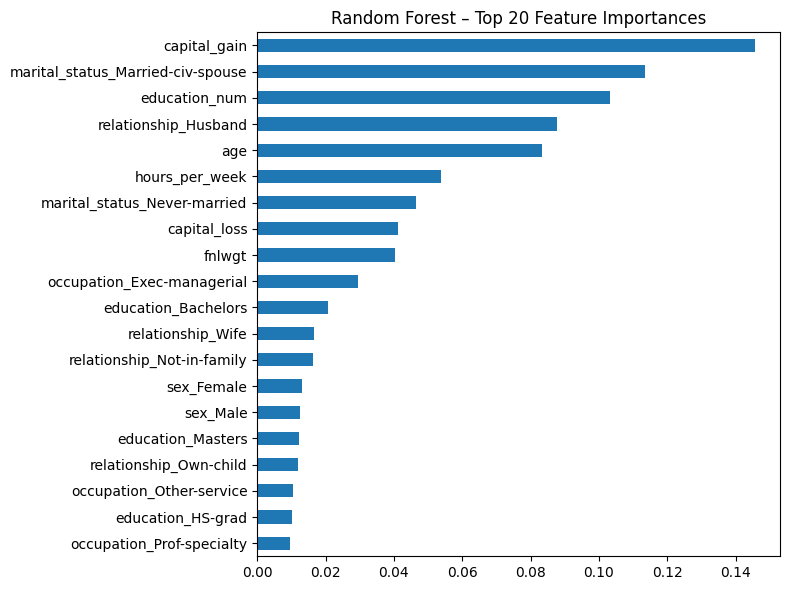

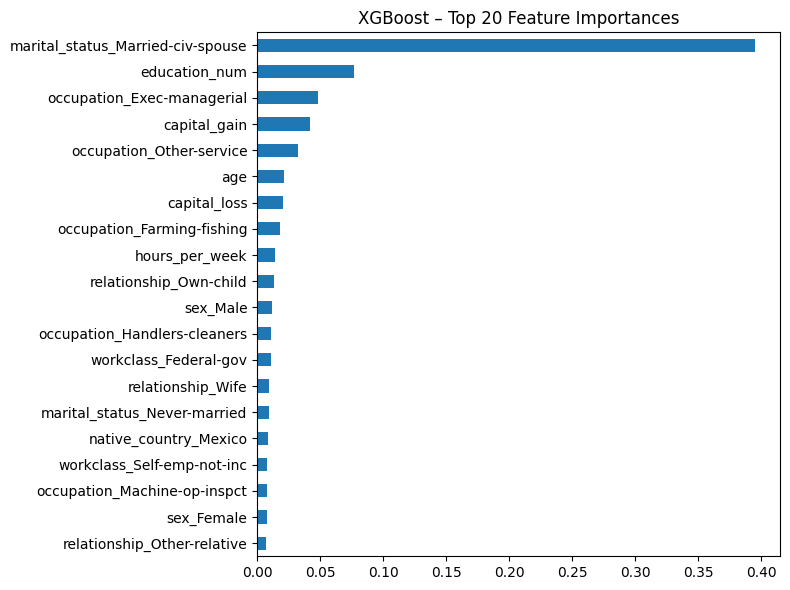

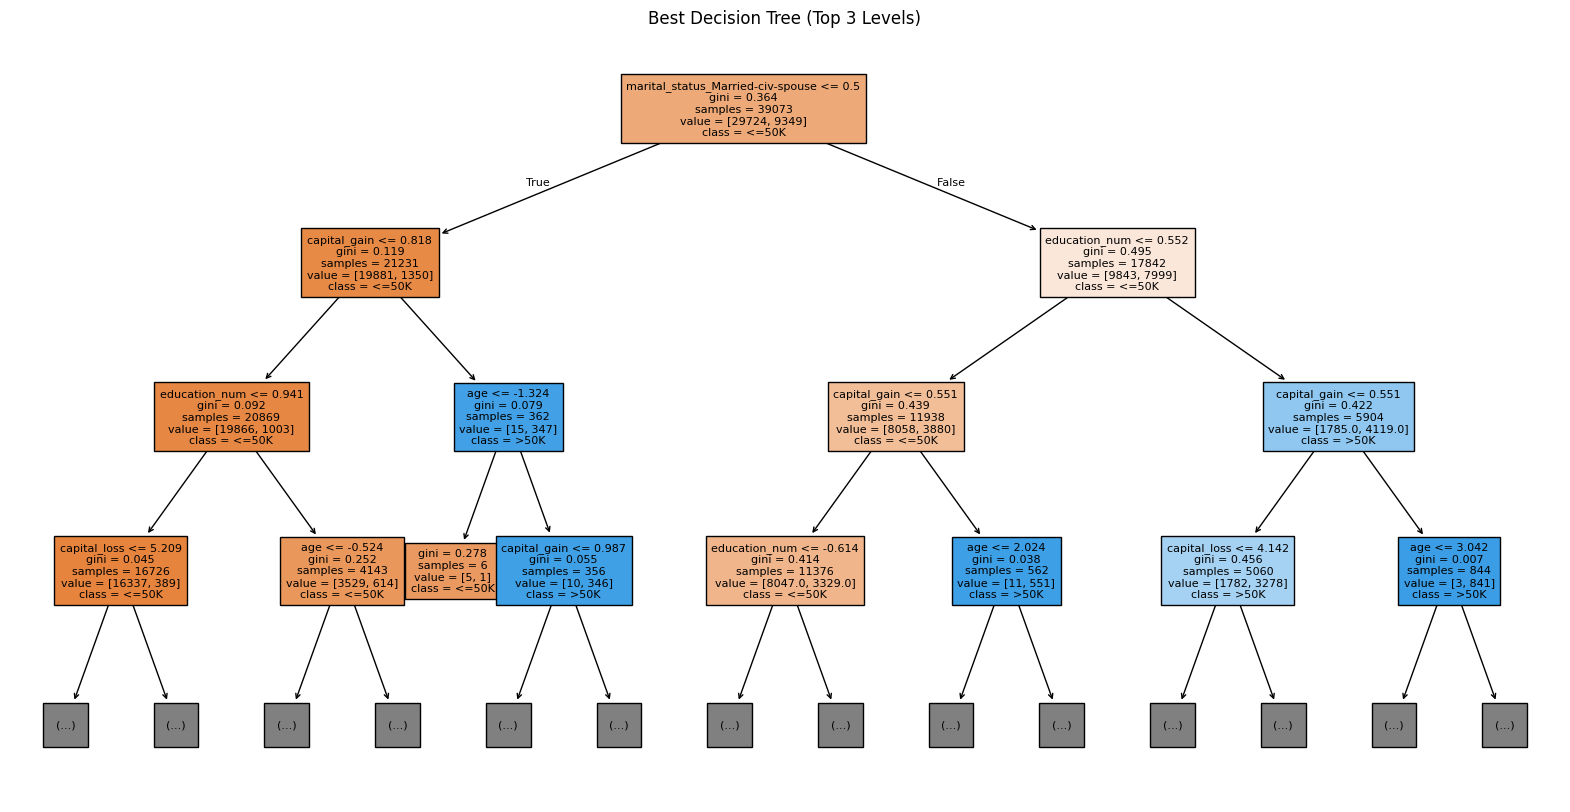

In [9]:
# ===== FAST one-cell Trees pipeline (hyphen->underscore fix) =====
HEAVY_GRID = False  # set True later for stronger (slower) tuning

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# Try XGBoost
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

np.random.seed(42)
pd.set_option("display.max_columns", 200)

print("Step 1/8: Loading dataset from OpenML...")
from sklearn.datasets import fetch_openml
data = fetch_openml('adult', version=2, as_frame=True)
df = data.frame.rename(columns={'class': 'income'})

# 🔧 Normalize column names (OpenML uses hyphens)
df.columns = df.columns.str.replace('-', '_', regex=False).str.strip()

# Keep/ensure consistent order
cols = [
    'age','workclass','fnlwgt','education','education_num','marital_status',
    'occupation','relationship','race','sex','capital_gain','capital_loss',
    'hours_per_week','native_country','income'
]
missing = [c for c in cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing expected columns after normalization: {missing}")
df = df[cols]

# Clean
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].astype(str).str.strip()
df = df.replace('?', np.nan)
df['income_num'] = (df['income'] == '>50K').astype(int)

numeric_features = ['age','fnlwgt','education_num','capital_gain','capital_loss','hours_per_week']
categorical_features = [c for c in df.columns if c not in numeric_features + ['income','income_num']]

X = df.drop(columns=['income','income_num'])
y = df['income_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print("  Shapes:", X_train.shape, X_test.shape, "| positive rate test:", round(y_test.mean(),3))

print("Step 2/8: Building preprocessors...")
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features)
    ],
    remainder="drop"
)

print("Step 3/8: Defining helpers...")
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 3-fold for speed

def run_search(model, param_grid, scoring="roc_auc"):
    pipe = Pipeline([("pre", preprocessor), ("model", model)])
    gs = GridSearchCV(pipe, param_grid, cv=cv, n_jobs=-1, scoring=scoring, verbose=0)
    gs.fit(X_train, y_train)
    return gs

def evaluate(gs, name, threshold=0.5):
    best = gs.best_estimator_
    proba = best.predict_proba(X_test)[:, 1]
    preds = (proba >= threshold).astype(int)

    print(f"\n=== {name} ===")
    print("Best params:", gs.best_params_)
    print("CV best ROC AUC:", round(gs.best_score_, 4))
    print("\nTest metrics:\n", classification_report(y_test, preds, digits=4))
    print("Test ROC AUC:", round(roc_auc_score(y_test, proba), 4))

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False)
    plt.title(f"{name} – Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()

    RocCurveDisplay.from_predictions(y_test, proba)
    plt.title(f"{name} – ROC Curve"); plt.show()
    PrecisionRecallDisplay.from_predictions(y_test, proba)
    plt.title(f"{name} – Precision–Recall Curve"); plt.show()

    return best

def feature_names_from_pipe(fitted_pipe):
    ohe = fitted_pipe.named_steps["pre"].named_transformers_["cat"].named_steps["ohe"]
    return numeric_features + list(ohe.get_feature_names_out(categorical_features))

def plot_top_importances(fitted_pipe, title, topn=20):
    names = feature_names_from_pipe(fitted_pipe)
    imp = fitted_pipe.named_steps["model"].feature_importances_
    s = pd.Series(imp, index=names).sort_values(ascending=False).head(topn)
    ax = s[::-1].plot(kind="barh", figsize=(8,6))
    ax.set_title(title); plt.tight_layout(); plt.show()

# Small vs heavy grids
DT_GRID = {
    "model__criterion": ["gini","entropy"],
    "model__max_depth": [None, 10] if not HEAVY_GRID else [None, 5, 10, 20],
    "model__min_samples_split": [2, 20] if not HEAVY_GRID else [2, 10, 50],
    "model__min_samples_leaf": [1, 5] if not HEAVY_GRID else [1, 5, 10],
}
RF_GRID = {
    "model__n_estimators": [300] if not HEAVY_GRID else [300, 600],
    "model__max_depth": [None, 12] if not HEAVY_GRID else [None, 10, 20],
    "model__max_features": ["sqrt"],
    "model__min_samples_leaf": [1, 3] if not HEAVY_GRID else [1, 5],
}
ADA_GRID = {
    "model__n_estimators": [300] if not HEAVY_GRID else [200, 400, 800],
    "model__learning_rate": [0.1, 0.5] if not HEAVY_GRID else [0.05, 0.1, 0.5, 1.0],
}
if HAS_XGB:
    XGB_GRID = {
        "model__n_estimators": [400] if not HEAVY_GRID else [400, 800],
        "model__max_depth": [3, 6] if not HEAVY_GRID else [3, 6, 8],
        "model__learning_rate": [0.1] if not HEAVY_GRID else [0.05, 0.1],
        "model__subsample": [0.8],
        "model__colsample_bytree": [0.8],
    }

print("Step 4/8: Training Decision Tree (GridSearchCV)...")
gs_dt = run_search(DecisionTreeClassifier(random_state=42), DT_GRID)
best_dt = evaluate(gs_dt, "Decision Tree")

print("Step 5/8: Training Random Forest (GridSearchCV)...")
gs_rf = run_search(RandomForestClassifier(random_state=42, n_jobs=-1), RF_GRID)
best_rf = evaluate(gs_rf, "Random Forest")

print("Step 6/8: Training AdaBoost (GridSearchCV)...")
gs_ada = run_search(AdaBoostClassifier(random_state=42), ADA_GRID)
best_ada = evaluate(gs_ada, "AdaBoost")

if HAS_XGB:
    print("Step 7/8: Training XGBoost (GridSearchCV)...")
    gs_xgb = run_search(XGBClassifier(
        objective="binary:logistic", eval_metric="logloss",
        tree_method="hist", random_state=42, n_jobs=-1
    ), XGB_GRID)
    best_xgb = evaluate(gs_xgb, "XGBoost")
else:
    print("Step 7/8: XGBoost not available in this runtime; skipping.")
    best_xgb = None

print("Step 8/8: Model comparison plots...")
models = {"Decision Tree": best_dt, "Random Forest": best_rf, "AdaBoost": best_ada}
if best_xgb is not None: models["XGBoost"] = best_xgb

plt.figure(figsize=(6,5))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name)
plt.title("ROC Curves – All Models"); plt.show()

plt.figure(figsize=(6,5))
for name, model in models.items():
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, name=name)
plt.title("Precision–Recall Curves – All Models"); plt.show()

# Feature importances (RF + XGB if present)
plot_top_importances(best_rf, "Random Forest – Top 20 Feature Importances", 20)
if best_xgb is not None:
    plot_top_importances(best_xgb, "XGBoost – Top 20 Feature Importances", 20)

# Visualize the best Decision Tree (top levels)
plt.figure(figsize=(20,10))
feat_names = feature_names_from_pipe(best_dt)
plot_tree(best_dt.named_steps["model"], feature_names=feat_names,
          class_names=["<=50K", ">50K"], filled=True, max_depth=3, fontsize=8)
plt.title("Best Decision Tree (Top 3 Levels)"); plt.show()
